In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import smarts_cerebellum.globals as gl

df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'regression_DTI.tsv'), sep = '\t')

controls = ['CUP_1001', 'CUP_1002', 'JHP_1001', 'JHP_1002', 'JHP_1004']
df = df[~df.subj_id.isin(controls)]

df['region_bilat'] = df['tract'].str[:3]
# all lesions flipped to the right
df.loc[(df.tract.str[-1] == 'L'), 'side'] = 'contralesional'
df.loc[(df.tract.str[-1] == 'R'), 'side'] = 'ipsilesional'

colours = ['red', 'skyblue'] # contra, ipsi

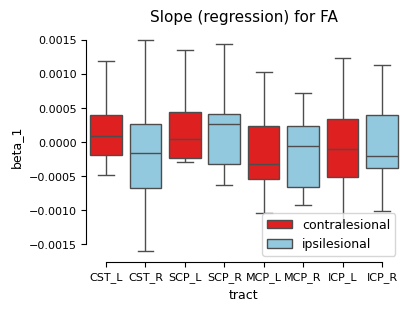

In [2]:
fig, ax = plt.subplots(figsize = (4,3), constrained_layout = True)
sns.boxplot(x = 'tract', y = 'beta_1', data = df, showfliers = False, hue = 'side', palette = colours)
plt.title("Slope (regression) for FA")
plt.legend(loc = 'lower right')
sns.despine(trim = True)
plt.show()

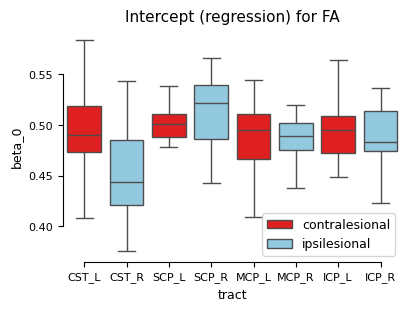

In [3]:
fig, ax = plt.subplots(figsize = (4,3), constrained_layout = True)
sns.boxplot(x = 'tract', y = 'beta_0', data = df, showfliers = False, hue = 'side', palette = colours)
plt.title("Intercept (regression) for FA")
plt.legend(loc = 'lower right')
sns.despine(trim = True)
plt.show()